In [2]:
import os

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
data_folder = "../../data/preprocessed-data"

df_rois = pd.concat(
    [pd.read_hdf(os.path.join(data_folder, f'df_eyewire2_roi_level_GCL{i}.h5'), key='dataframe') for i in range(5)])

In [4]:
from scipy import ndimage
import numpy as np

def downsample_uniform_filter(data, n):
    """Downsample using uniform filter - works with any array size"""
    filtered = ndimage.uniform_filter1d(data, size=n, axis=1)
    return filtered[:, ::n]

In [5]:
chirps = np.vstack(df_rois['chirp_average_norm'])

In [6]:
chirps.shape

(379, 1982)

In [7]:
bars = np.vstack(df_rois['bar_time_component'])

In [8]:
df_rois.supergroup.unique()

array(['ON-OFF', 'dAC', 'Slow ON', 'Fast ON', 'Unc. ON', 'OFF',
       'Unc. SbC'], dtype=object)

In [9]:
def sg_to_int(sg):
    if sg == 'OFF':
        return 0
    elif sg == 'ON-OFF':
        return 1
    elif sg == 'Fast ON':
        return 2
    elif sg == 'Slow ON':
        return 3
    elif sg == 'Unc. ON':
        return 4
    elif sg == 'Unc. SbC':
        return 5
    elif sg == 'dAC':
        return 6

supergroups = df_rois.supergroup.values
supergroups_int = np.array([sg_to_int(sg) for sg in supergroups])

In [10]:
sidx = np.argsort(df_rois.group_id.values)[::-1]

In [11]:
import h5py

try:
    with h5py.File("X:/Resources/Stimulus/chirp.h5", "r") as f:
        chirp_stimulus = f['stimulusarray'][:].T.astype(int)
    chirp_stimulus = np.append(chirp_stimulus, np.full(1000, chirp_stimulus[-1]))
except:
    chirp_stimulus = np.ones(32988).astype(int)

In [12]:
import seaborn as sns

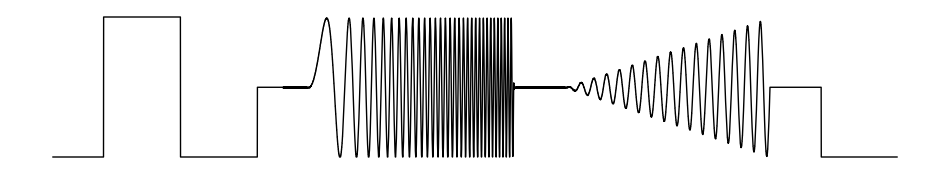

In [13]:

fig, ax = plt.subplots(1, 1, figsize=(12, 2))

ax.axis('off')
ax.plot(np.arange(len(chirp_stimulus))*1e-3, chirp_stimulus, c='k', clip_on=False, lw=1, solid_capstyle='butt')
plt.savefig('figures/chirp_stimulus.eps', bbox_inches='tight')

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

supergroups_u_int = np.arange(7)
sg_cmap = ListedColormap([
    "darkred",  # for 0
    "orange",  # for 1
    "green",  # for 2
    "darkblue",  # for 3
    "royalblue",  # for 4
    "purple",  # for 5
    "gray"   # for 6
])
bounds = np.arange(-0.5+supergroups_u_int[0], supergroups_u_int[-1]+0.6, 1)
sg_norm = BoundaryNorm(bounds, sg_cmap.N)

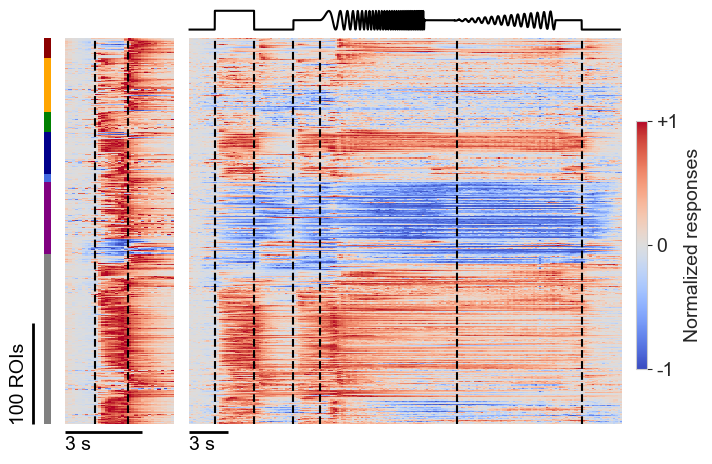

In [15]:
f_ds = 10

fig, axs = plt.subplots(2, 4, figsize=(7, 5), width_ratios=(0.5, 3, 12, 0.3), height_ratios=(1, 20), sharex='col')
sns.despine(left=1, bottom=1)

ax = axs[1, 0]
ax.axis('off')
im = ax.imshow(supergroups_int[sidx, np.newaxis], aspect='auto',
               cmap=sg_cmap, norm=sg_norm,
               interpolation='none', extent=(0, 1, 0, 1), origin='lower')
ax.plot([0, 1], [-.02, -.02], c=(1, 1, 1, 0), solid_capstyle='butt', lw=2)
ax.text(0, -0.03, ' ', c=(1, 1, 1, 0), ha='left', rotation=0, va='top', fontsize=14)

ax = axs[0, 2]
ax.axis('off')
ax.plot(np.arange(len(chirp_stimulus))*1e-3, chirp_stimulus, c='k', clip_on=False, lw=1.5, solid_capstyle='butt')

ax = axs[1, 2]
ax.grid(False)
ax.set(xticks=[], yticks=[])
ax.imshow(downsample_uniform_filter(data=chirps[sidx], n=f_ds), aspect='auto', vmin=-1, vmax=1, cmap='coolwarm', interpolation='none', extent=(0, 33, 0, 1), origin='lower')
for t in [2, 5, 8, 10, 20.5, 30]:
    ax.plot([t, t], [0, 1], c='k', lw=1.5, ls='--')
ax.plot([0, 3], [-.02, -.02], c='k', solid_capstyle='butt', lw=2)
ax.text(0, -0.03, '3 s', c='k', ha='left', rotation=0, va='top', fontsize=14)

ax = axs[0, 1]
ax.axis('off')

ax = axs[0, 0]
ax.axis('off')

ax = axs[0, 3]
ax.axis('off')

ax = axs[1, 1]
ax.grid(False)
ax.axis('off')
im = ax.imshow(bars[sidx], aspect='auto', vmin=-1, vmax=1, cmap='coolwarm', interpolation='none', extent=(0, 4.224, 0, 1), origin='lower')

for t in [1.152, 2.432]:
    ax.plot([t, t], [0, 1], c='k', lw=1.5, ls='--')
ax.plot([0, 3], [-.02, -.02], c='k', solid_capstyle='butt', lw=2)
ax.text(0, -0.03, '3 s', c='k', ha='left', rotation=0, va='top', fontsize=14)

ax = axs[1, 3]
cbar = plt.colorbar(im, ax=ax, cax=ax, orientation='vertical')
cbar.set_label('Normalized responses', fontsize=14)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["-1", "0", "+1"], fontsize=14)

plt.tight_layout(h_pad=0.05)

ax = axs[1, 0]
ax.set_ylabel('Cells sorted by functional group', fontsize=14)
dscale = 80
ax.plot([-0.02*dscale, -0.02*dscale], [0, 100/len(sidx)], c='k', solid_capstyle='butt', lw=2, clip_on=False)
ax.text(-0.03*dscale, 0, f'100 ROIs', c='k', ha='right', rotation=90, va='bottom', fontsize=14)

ax = axs[-1, -1]
pos = ax.get_position()
new_pos = [pos.x0, pos.y0 + pos.height*0.2, pos.width, pos.height*0.6]
ax.set_position(new_pos)

plt.savefig('figures/response_overview.svg', bbox_inches='tight')